In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [19]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB


In [21]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [22]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

In [23]:
X = df[['Annual Income (k$)' ,'Spending Score (1-100)']]
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [24]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [28]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i,init="k-means++",random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [29]:
wcss

[399.99999999999994,
 273.6688866264201,
 157.70400815035947,
 109.22822707921347,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091,
 30.05932269404221]

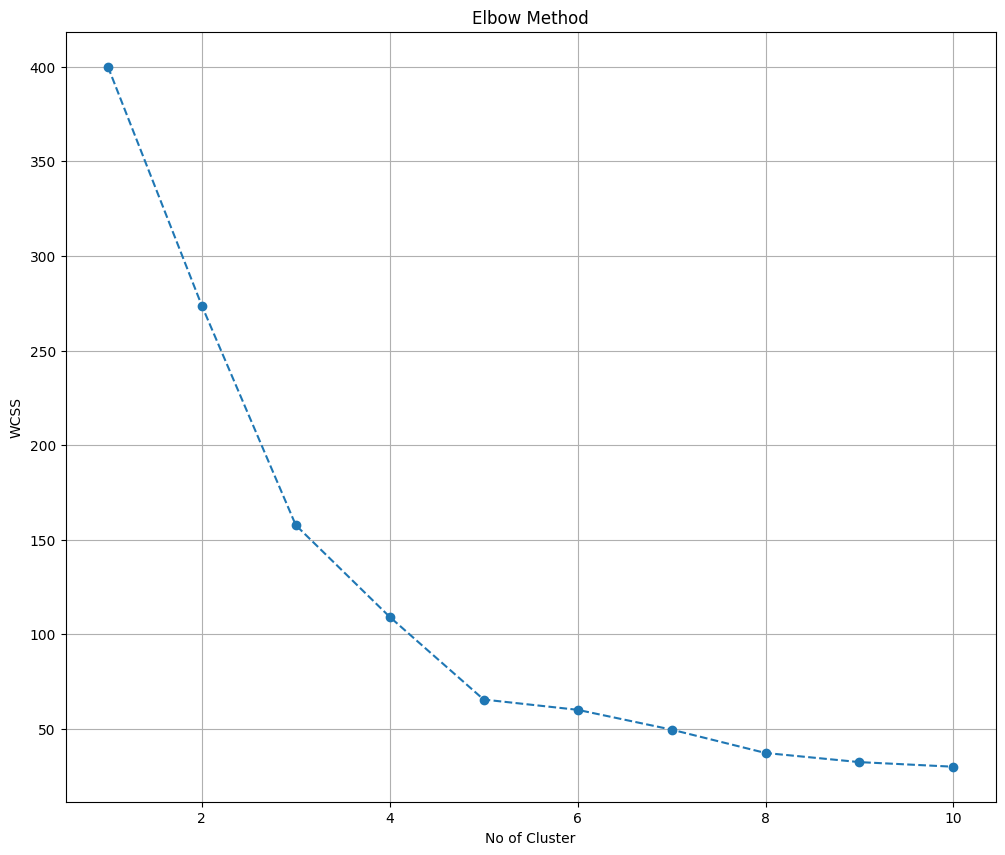

In [37]:
plt.figure(figsize=(12,10))
plt.plot(range(1,11),wcss,marker = 'o', linestyle='--')
plt.title("Elbow Method")
plt.xlabel("No of Cluster")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [38]:
k = 5
kmeans = KMeans(n_clusters=k,init='k-means++',random_state=42)

In [39]:
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [41]:
score = silhouette_score(X_scaled,clusters)
print(f"silhouette_score:{score:.4f}")

silhouette_score:0.5547


In [44]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centers,columns=['Annual Income (k$)','Spending Score (1-100)']))

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


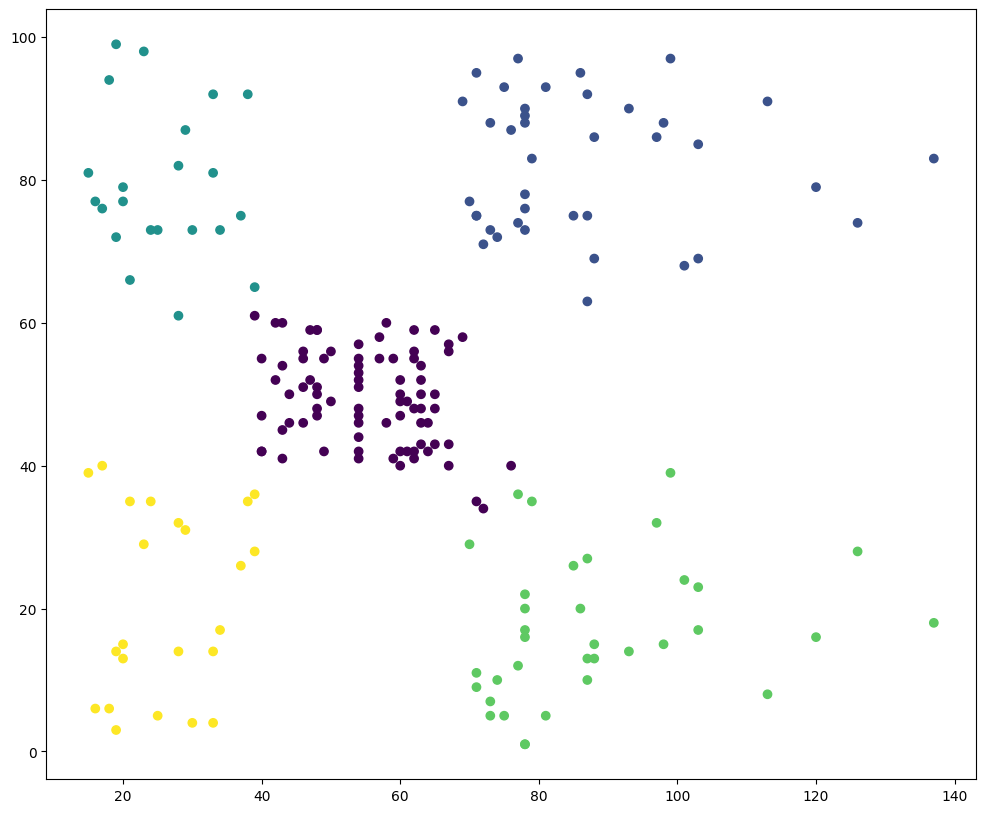

In [49]:
plt.figure(figsize=(12,10))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c = df['Cluster'],
    cmap= 'viridis',
    marker='o')

plt.show()


C:\Users\Acer\AppData\Local\Temp\ipykernel_6884\3845434150.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper center')


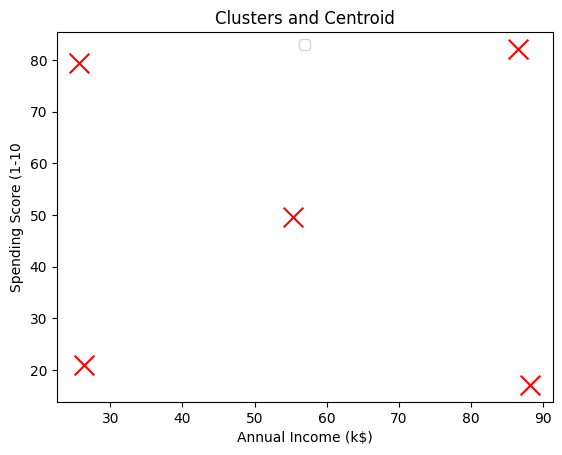

In [55]:
plt.scatter(
    centers[:,0],
    centers[:,1],
    s=200,marker='x',
    c = 'red'


)
plt.title('Clusters and Centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-10')
plt.legend(loc='upper center')

In [56]:
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [60]:
for i in range(k):
    cluster_data = df[df['Cluster'] == i]
    print('Customers:', len(cluster_data))
    print('Average Annual Income:', cluster_data['Annual Income (k$)'].mean())
    print('Average Spending Score:', cluster_data['Spending Score (1-100)'].mean())

Customers: 81
Average Annual Income: 55.2962962962963
Average Spending Score: 49.51851851851852
Customers: 39
Average Annual Income: 86.53846153846153
Average Spending Score: 82.12820512820512
Customers: 22
Average Annual Income: 25.727272727272727
Average Spending Score: 79.36363636363636
Customers: 35
Average Annual Income: 88.2
Average Spending Score: 17.114285714285714
Customers: 23
Average Annual Income: 26.304347826086957
Average Spending Score: 20.91304347826087
